In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import functools
conn = duckdb.connect()
@functools.lru_cache(maxsize=1024)
def q(query: str):
    return conn.execute(query).df()

In [7]:
q('''select * from '../traces/fb23/reag.parquet' limit 3''')

,timestamp,cacheKey,OpType,objectSize,responseSize,responseHeaderSize,rangeStart,rangeEnd,TTL,SamplingRate,cache_hit,item_value,RequestHandler,cdn_content_type_id,vip_type
0,1678863509425,0067813353300000000000000000000000000000000000...,1,-1,246307,547,-1,-1,1209600,0.0001,0,1,1000,9,2000
1,1678863511382,0067813353400000000000000000000000000000000000...,1,-1,2736128,0,-1,-1,1209600,0.0001,0,1,1000,2,2000
2,1678863569821,0067813353500000000000000000000000000000000000...,1,25568,26063,450,-1,-1,1209600,0.0001,0,1,1000,15,2000


In [21]:
q('''select * from '../traces/cf/**/*.parquet' limit 3''')

,timestamp,key,zone,size,expiry_time,stale_time,method,mime,server
0,1745712000,28e3c4805dc376c3,a9deca06e76f5a50,161189,300,0,0,text/html,106m105
1,1745712000,5bb1c025b485e25e,e579e303a6479bc2,242,14400,0,0,application/json,106m105
2,1745712000,5bb1c025b485e25e,e579e303a6479bc2,242,14400,0,0,application/json,106m105


In [22]:
q('''select * from '../traces/wm/*.parquet' limit 3''')

,timestamp,key,size
0,86400,-719785930,12319
1,86400,566297063,34510
2,86400,1252933015,47354


In [7]:
exp_cols = ['ts', 'next_ts', 'ttl', 'create_ts', 'freq', 'last_ts', 'update_ts', 'revals', 'good_rv', 'bad_rv', 'mime', 'size']
cols_struct = ', '.join([f"'{col}': '{dtype}'" for col, dtype in zip(exp_cols, ['BIGINT'] * 7 + ['INT'] * 3 + ['VARCHAR', 'BIGINT'])])
cols_struct = f'{{ {cols_struct} }}'
q(f'''select * from read_csv('../traces/expiry/r8cf_a.csv.zst', columns={cols_struct}) limit 3''')

,ts,next_ts,ttl,create_ts,freq,last_ts,update_ts,revals,good_rv,bad_rv,mime,size
0,6,15,1,4,1,4,4,0,0,0,3,15495
1,7,61,5,1,1,1,1,0,0,0,3,1067
2,8,0,6,1,4,1,1,0,0,0,6,606


# fig 1: distribtion of miss types in baseline

In [6]:
files = [
    '../results/r8i1_baseline.csv',
]
df = pd.concat([pd.read_csv(f) for f in files])

df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['miss_mandatory_pct'] = df.miss_mandatory / df.miss_all
df['miss_expired_pct'] = df.miss_expired / df.miss_all
df['miss_evicted_pct'] = df.miss_evicted / df.miss_all
df.head()

,in,gib,ksr,mode,model,mlthres,rv_min_ttl,rv_min_freq,rv_max_za,all,...,miss_mandatory,miss_expired,miss_evicted,fetches,revals,reval_wasted,miss_all,miss_mandatory_pct,miss_expired_pct,miss_evicted_pct
0,fb_c,2048,1,never,NaN,1,0,0,0,96068462,...,34573735,0,9726350,44300085,0,0,44300085,0.780444,0.0,0.219556
1,fb_b,2048,1,never,NaN,1,0,0,0,102876031,...,36942103,0,14859929,51802032,0,0,51802032,0.713140,0.0,0.286860
2,wm_t,2048,1,never,NaN,1,0,0,0,197819321,...,17895056,0,28975699,46870755,0,0,46870755,0.381796,0.0,0.618204
3,fb_a,2048,1,never,NaN,1,0,0,0,50113746,...,14705869,0,2213376,16919245,0,0,16919245,0.869180,0.0,0.130820
4,fb_a,2048,1,never,NaN,1,0,0,0,50113746,...,14705869,0,2213376,16919245,0,0,16919245,0.869180,0.0,0.130820


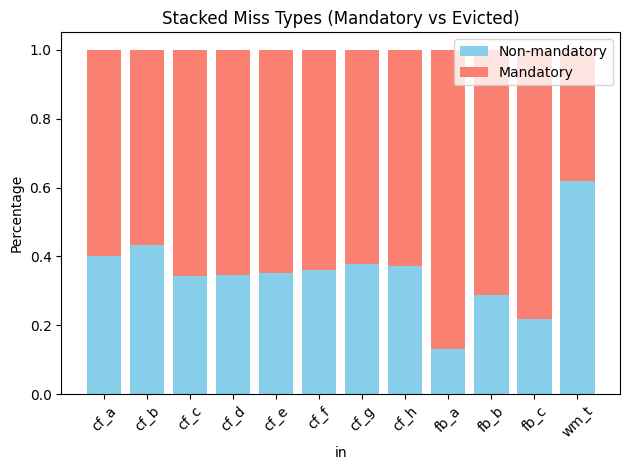

In [14]:
# get stacked bar plot of miss types
miss_types = df[['in', 'miss_mandatory_pct', 'miss_evicted_pct']]
miss_types = miss_types.sort_values(by='in')
plt.bar(miss_types['in'], miss_types['miss_evicted_pct'], label='Non-mandatory', color='skyblue')
plt.bar(miss_types['in'], miss_types['miss_mandatory_pct'], bottom=miss_types['miss_evicted_pct'], label='Mandatory', color='salmon')
plt.xlabel('in')
plt.ylabel('Percentage')
plt.title('Stacked Miss Types (Mandatory vs Evicted)')
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()

# singletons

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

      trace        a1        a2        a3        a4        a5
0   106m105  0.618616  0.138077  0.061066  0.035303  0.022956
1   106m106  0.609606  0.138460  0.062206  0.036132  0.023635
2    243m12  0.724098  0.119791  0.046256  0.024513  0.015102
3    243m13  0.719716  0.121518  0.047055  0.024867  0.015312
4   411m264  0.680582  0.117483  0.050477  0.029037  0.019100
5   411m325  0.681081  0.117205  0.050370  0.029005  0.019042
6   472m378  0.643981  0.133685  0.060799  0.033471  0.021841
7   472m379  0.641567  0.134312  0.061525  0.033888  0.022157
8      reag  0.650057  0.208726  0.053713  0.026738  0.013599
9      rhna  0.601497  0.218376  0.060836  0.033725  0.019814
10     rprn  0.666966  0.167583  0.055252  0.030685  0.018773
11     wm_t  0.558991  0.138926  0.066806  0.040476  0.027484


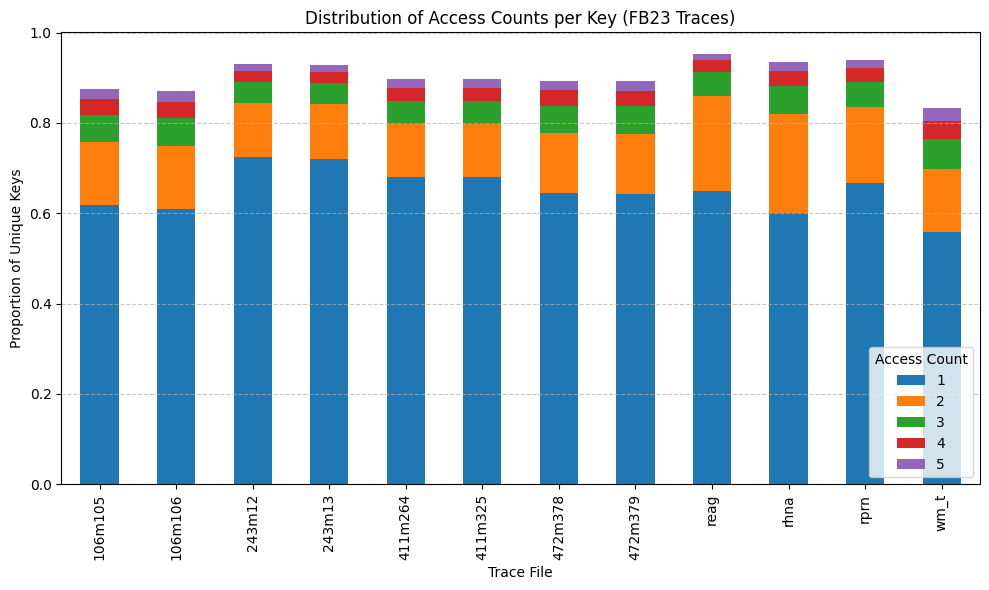

In [11]:
# Execute the query
df = q("""
WITH key_counts AS (
    SELECT 'reag' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/reag.parquet' GROUP BY key
    UNION ALL
    SELECT 'rhna' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/rhna.parquet' GROUP BY key
    UNION ALL
    SELECT 'rprn' AS trace, cacheKey as key, COUNT(*) AS access_count FROM '../traces/fb23/rprn.parquet' GROUP BY key
    UNION ALL
    SELECT server AS trace, key, COUNT(*) AS access_count FROM '../traces/cf/**/*.parquet' GROUP BY server, key
    UNION ALL
    SELECT 'wm_t' AS trace, key, COUNT(*) AS access_count FROM '../traces/wm/t-all.parquet' GROUP BY key
)
SELECT
    trace,
    SUM(CASE WHEN access_count = 1 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a1,
    SUM(CASE WHEN access_count = 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a2,
    SUM(CASE WHEN access_count = 3 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a3,
    SUM(CASE WHEN access_count = 4 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a4,
    SUM(CASE WHEN access_count = 5 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS a5
FROM key_counts
GROUP BY trace
ORDER BY trace
""")

# Display Table
print(df)

# Create Stacked Bar Chart
df.set_index('trace').plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Distribution of Access Counts per Key (FB23 Traces)')
plt.ylabel('Proportion of Unique Keys')
plt.xlabel('Trace File')
plt.legend(title='Access Count', labels=['1', '2', '3', '4', '5'], loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# TTL distributions

In [2]:
df = q("""
WITH ttls AS (
    -- Floored TTL to the minute (units: minutes)
    SELECT 
        'fb_reag' AS trace, 
        FLOOR(ttl / 60) AS ttl_min, 
        COUNT(DISTINCT cacheKey) AS key_count 
    FROM '../traces/fb23/reag.parquet' 
    GROUP BY ttl_min
    
    UNION ALL
    
    SELECT 
        'fb_rhna' AS trace, 
        FLOOR(ttl / 60) AS ttl_min, 
        COUNT(DISTINCT cacheKey) AS key_count 
    FROM '../traces/fb23/rhna.parquet' 
    GROUP BY ttl_min
    
    UNION ALL
    
    SELECT 
        'fb_rprn' AS trace, 
        FLOOR(ttl / 60) AS ttl_min, 
        COUNT(DISTINCT cacheKey) AS key_count 
    FROM '../traces/fb23/rprn.parquet' 
    GROUP BY ttl_min
    
    UNION ALL
    
    SELECT 
        server AS trace, 
        FLOOR(expiry_time / 60) AS ttl_min, 
        COUNT(DISTINCT key) AS key_count 
    FROM '../traces/cf/**/*.parquet' 
    GROUP BY server, ttl_min
)
SELECT trace, ttl_min, key_count FROM ttls
""")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for trace in sorted(df['trace'].unique()):
    subset = df[df['trace'] == trace].sort_values('ttl_min')
    
    # Calculate the key-weighted CDF
    subset['cum_keys'] = subset['key_count'].cumsum()
    subset['cdf'] = subset['cum_keys'] / subset['key_count'].sum()
    
    plt.step(subset['ttl_min'], subset['cdf'], label=trace, where='post')

# X-axis formatting
plt.xscale('log')
plt.xlabel('TTL (minutes)')
plt.ylabel('CDF (Fraction of Unique Keys)')
plt.title('Key-Weighted CDF of TTLs (in Minutes)')

# Standardize ticks for easier reading
# 1m, 1h, 1d, 1w, 30d
ticks = [1, 60, 1440, 10080, 43200]
labels = ['1m', '1h', '1d', '1w', '30d']
plt.xticks(ticks, labels)

plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend(title='Trace Source')
plt.tight_layout()
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Error: KeyboardInterrupt: <EMPTY MESSAGE>

At:
  /home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/traitlets/traitlets.py(708): __set__
  /tmp/ipykernel_644548/1819365042.py(10): q
  /tmp/ipykernel_644548/3309885566.py(1): <module>
  /home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py(3699): run_code
  /home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py(3639): run_ast_nodes
  /home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py(3394): run_cell_async
  /home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/async_helpers.py(128): _pseudo_sync_runner
  /home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py(3171): _run_cell
  /home/isaackhor/code/cfcache/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py(3116): run_cell
  /home/isaackhor/code/cfcache/.venv/lib/pyth

In [ ]:
# Expiry events distribution of TTLs


# results - oracle / ml tradeoff curves

In [35]:
files = [
    '../results/r8i1_baseline.csv',
    '../results/r8i1_oracle.csv',
    '../results/r8i1_ml_cf_rfc.csv',
    '../results/r8i1_ml_fb_rfc.csv',
]
df = pd.concat([pd.read_csv(f) for f in files])

df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['rv_pending'] = df.revals - df.hit_reval - df.reval_wasted
df['optmiss'] = (df['miss_all'] - df['miss_mandatory']) / df['all'] * 100
df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['rv_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg'] = (df['amp_lower'] + df['amp_upper']) / 2
df.head()

,in,gib,ksr,mode,model,mlthres,rv_min_ttl,rv_min_freq,rv_max_za,all,...,miss_evicted,fetches,revals,reval_wasted,miss_all,rv_pending,optmiss,amp_lower,amp_upper,amp_avg
0,fb_c,2048,1,never,NaN,1.0,0,0,0,96068462,...,9726350,44300085,0,0,44300085,0,10.124394,1.0,1.0,1.0
1,fb_b,2048,1,never,NaN,1.0,0,0,0,102876031,...,14859929,51802032,0,0,51802032,0,14.444501,1.0,1.0,1.0
2,wm_t,2048,1,never,NaN,1.0,0,0,0,197819321,...,28975699,46870755,0,0,46870755,0,14.647558,1.0,1.0,1.0
3,fb_a,2048,1,never,NaN,1.0,0,0,0,50113746,...,2213376,16919245,0,0,16919245,0,4.416704,1.0,1.0,1.0
4,fb_a,2048,1,never,NaN,1.0,0,0,0,50113746,...,2213376,16919245,0,0,16919245,0,4.416704,1.0,1.0,1.0


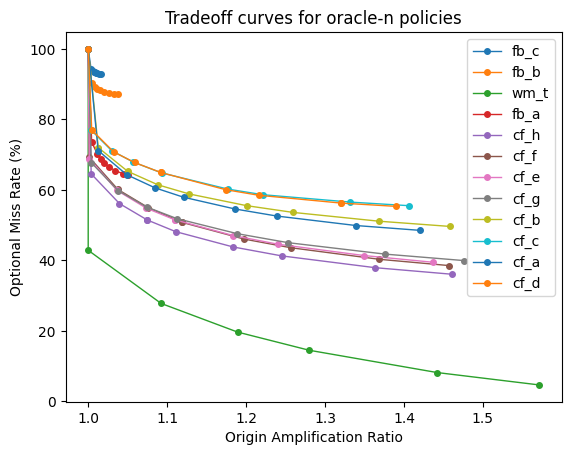

In [51]:
oracledf = df[(df['mode'] == 'oracle') | (df['mode'] == 'never')][['in', 'mlthres', 'optmiss', 'amp_avg']]
for i in oracledf['in'].unique():
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i)]['optmiss'].values[0]
    subset = oracledf[oracledf['in'] == i].sort_values(by='amp_avg')
    subset = subset[subset['amp_avg'] < 1.6]
    plt.plot(subset['amp_avg'], subset['optmiss'] / nevermax * 100, marker='o', ms=4, linewidth=1, label=i)
plt.legend()
plt.title('Tradeoff curves for oracle-n policies')
plt.xlabel('Origin Amplification Ratio')
plt.ylabel('Optional Miss Rate (%)')
plt.savefig('../paper/figs/oracle_tradeoff.png')

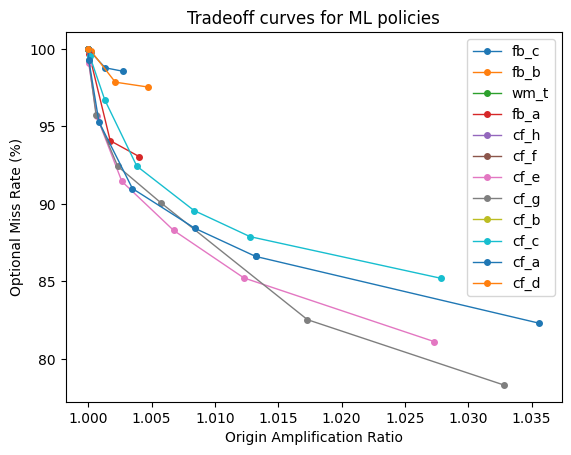

In [57]:
mldf = df[(df['mode'] == 'ml') | (df['mode'] == 'never')][['in', 'mlthres', 'optmiss', 'amp_avg']]
for i in mldf['in'].unique():
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i)]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    subset = subset[subset['amp_avg'] < 1.1]
    plt.plot(subset['amp_avg'], subset['optmiss'] / nevermax * 100, marker='o', ms=4, linewidth=1, label=i)
plt.legend()
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Origin Amplification Ratio')
plt.ylabel('Optional Miss Rate (%)')
plt.savefig('../paper/figs/ml_tradeoff_norm.png')

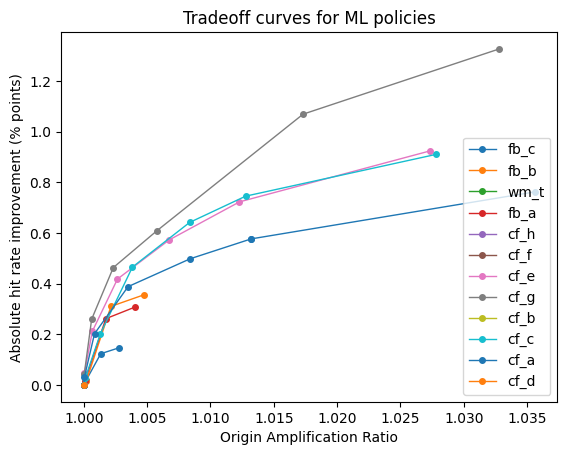

In [59]:
mldf = df[(df['mode'] == 'ml') | (df['mode'] == 'never')][['in', 'mlthres', 'optmiss', 'amp_avg']]
for i in mldf['in'].unique():
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i)]['optmiss'].values[0]
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    subset = subset[subset['amp_avg'] < 1.1]
    plt.plot(subset['amp_avg'], nevermax - subset['optmiss'], marker='o', ms=4, linewidth=1, label=i)
plt.legend()
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Origin Amplification Ratio')
plt.ylabel('Absolute hit rate improvement (% points)')
plt.savefig('../paper/figs/ml_tradeoff_abs.png')

Dataset: fb_c, Never Max: 10.124394413642221, Oracle@1 Min: 9.55927555080459
Dataset: fb_b, Never Max: 14.44450068257396, Oracle@1 Min: 13.062362407818787
Dataset: wm_t, Never Max: 14.647557606367478, Oracle@1 Min: 6.280719161906334
Dataset: fb_a, Never Max: 4.416704350937964, Oracle@1 Min: 3.2514951087472084
Dataset: cf_h, Never Max: 5.364981161375973, Oracle@1 Min: 3.463714481006867
Dataset: cf_f, Never Max: 4.767110241992377, Oracle@1 Min: 3.3023568824542613
Dataset: cf_e, Never Max: 4.888685561316794, Oracle@1 Min: 3.3661083352896424
Dataset: cf_g, Never Max: 6.115635089860658, Oracle@1 Min: 4.141698651706156
Dataset: cf_b, Never Max: 4.714959030121822, Oracle@1 Min: 3.394188399280393
Dataset: cf_c, Never Max: 6.149779949232551, Oracle@1 Min: 4.730841472093821
Dataset: cf_a, Never Max: 4.304472958917405, Oracle@1 Min: 3.0637981463624318
Dataset: cf_d, Never Max: 6.24237268707982, Oracle@1 Min: 4.807034921475476


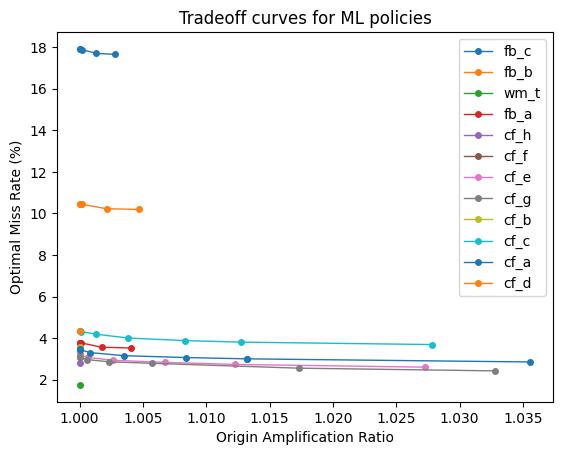

In [50]:
mldf = df[(df['mode'] == 'ml') | (df['mode'] == 'never')][['in', 'mlthres', 'optmiss', 'amp_avg']]
for i in mldf['in'].unique():
    nevermax = df[(df['mode'] == 'never') & (df['in'] == i)]['optmiss'].values[0]
    o1min = df[(df['mode'] == 'oracle') & (df['in'] == i) & (df['mlthres'] == 1)]['optmiss'].min()
    print(f"Dataset: {i}, Never Max: {nevermax}, Oracle@1 Min: {o1min}")
    subset = mldf[mldf['in'] == i].sort_values(by='amp_avg')
    subset = subset[subset['amp_avg'] < 1.1]
    plt.plot(subset['amp_avg'], subset['optmiss'] / (nevermax - o1min), marker='o', ms=4, linewidth=1, label=i)
plt.legend()
plt.title('Tradeoff curves for ML policies')
plt.xlabel('Origin Amplification Ratio')
plt.ylabel('Optimal Miss Rate (%)')
plt.savefig('../paper/figs/ml_tradeoff_oracle1.png')

In [42]:
mldf['in'].unique()

array(['fb_c', 'fb_b', 'wm_t', 'fb_a', 'cf_h', 'cf_f', 'cf_e', 'cf_g',
       'cf_b', 'cf_c', 'cf_a', 'cf_d'], dtype=object)